# Examen Programme FORCE_N

**GROUPE 1:** Samilou, Saliou

## Importation des modules

In [18]:
# Importation des modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Importation des données

In [19]:
# Importation des données
df = pd.read_csv('wfp_food_prices_sen.csv')

## Exploitation des données

In [20]:
# Visualisation des données et la comprehension des données
print(df.sample(10).to_string(index=False))

      date      admin1      admin2    market  market_id  latitude  longitude           category              commodity  commodity_id unit priceflag pricetype currency  price  usdprice
2019-08-15       Kolda       Kolda     Kolda        421     12.88     -14.95 cereals and tubers                Sorghum            65   KG    actual    Retail      XOF  250.0      0.43
2014-01-15  Ziguinchor     Bignona   Bignona        407     12.81     -16.23 cereals and tubers        Rice (imported)            64   KG    actual    Retail      XOF  300.0      0.62
2024-06-15      Fatick      Fatick   Diakhao        411     14.47     -16.30 cereals and tubers        Rice (imported)            64   KG    actual    Retail      XOF  442.0      0.72
2025-05-15       Kolda       Kolda Sare Yoba        439     12.77     -15.11 cereals and tubers                 Millet            73   KG    actual    Retail      XOF  300.0      0.52
2020-02-15       Thies    Tivaoune Thilmakha        445     15.03     -16.25 cer

### Exploration des données

In [21]:
# Aperçu général de la structure des données
print('\nDimensions du dataframe : ', df.shape)
print('Nombre de doublons : ', df.duplicated().sum())
print('\nInformation sur le dataframe : \n')
print(df.info())
print()
print("Régions (admin1)  :", df['admin1'].nunique())
print("Départements (admin2) :", df['admin2'].nunique())
print("Marchés :", df['market'].nunique())
print("Catégories :", list(df['category'].unique()))
print("Produits :", list(df['commodity'].unique()))
print("Type de prix :", list(df['pricetype'].unique()))
print("Unité :", list(df['unit'].unique()))
print("Devise :", list(df['currency'].unique()))
print()
print("Valeurs manquantes par colonne :")
print(df.isna().sum())


Dimensions du dataframe :  (50060, 16)
Nombre de doublons :  0

Information sur le dataframe : 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50060 entries, 0 to 50059
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          50060 non-null  object 
 1   admin1        50060 non-null  object 
 2   admin2        50060 non-null  object 
 3   market        50060 non-null  object 
 4   market_id     50060 non-null  int64  
 5   latitude      50060 non-null  float64
 6   longitude     50060 non-null  float64
 7   category      50060 non-null  object 
 8   commodity     50060 non-null  object 
 9   commodity_id  50060 non-null  int64  
 10  unit          50060 non-null  object 
 11  priceflag     50060 non-null  object 
 12  pricetype     50060 non-null  object 
 13  currency      50060 non-null  object 
 14  price         50060 non-null  float64
 15  usdprice      50060 non-null  float64
dtypes: float64(4),

**Remarque sur la structure du jeu de données** : 

le dataset couvre 14 régions, 34 départements et 64 marchés au Sénégal, sur la période 2000–2026. Il ne contient que 2 catégories de produits (*cereals and tubers* et *pulses and nuts*) et 12 produits, exclusivement en type de prix **Retail** (détail) et en unité **KG**. Cette homogénéité de collecte sera importante pour la question 8.

### Correction des formats de données

In [22]:
# Correction de la date
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
df['date'].dtype

dtype('<M8[ns]')

### Analyse descriptive et diagnostique 

In [23]:
# Statistiques descriptives des prix des produits sur le marché Sénégalais
print('\nStatistiques descriptives des prix :\n')

print(df.describe().round(2)[['price','usdprice']].to_string(index=True))


Statistiques descriptives des prix :

          price  usdprice
count  50060.00  50060.00
mean     332.23      0.60
min       90.00      0.19
25%      216.67      0.42
50%      275.00      0.51
75%      360.00      0.64
max     1816.50      2.95
std      198.45      0.32


**Remarque :**

Le prix moyen des produits vendues sur l’étant des marchés est de 332 XOF soit 0.60 USD. Cette moyenne est fortement influencé par un prix maximal de produit qui de 1816 XOF (2.95 USD) soit une difference de 1726 XOF par rapport au prix minimum de produit qui est de 90 XOF (0.19 USD).
Le prix des produits mediant est de 275 XOF soit 0.51 USD.

#### **1. Les produits alimentaires les plus chers dans les différents marchés du Sénégal**

 On regroupe les prix des produit par marché puis on enregistre le produit le plus chers de chaque marché.


 Top 10 des marchés avec le prix ponctuel le plus élevé enregistré, et le produit concerné :

            admin1       market             commodity   price
34656        Dakar     Thiaroye         Beans (niebe)  1816.5
39079  Saint Louis  Saint-Louis         Beans (niebe)  1800.0
34870      Sedhiou      Sedhiou         Beans (niebe)  1700.0
48726  Tambacounda        Bakel  Groundnuts (shelled)  1500.0
38992     Kedougou     Kedougou  Groundnuts (shelled)  1500.0
34665     Diourbel       Bambey         Beans (niebe)  1500.0
34946   Ziguinchor      Bignona  Groundnuts (shelled)  1500.0
34414       Fatick       Fatick         Beans (niebe)  1500.0
41378        Matam   Ourossogui         Beans (niebe)  1500.0
34684     Diourbel       Ndindy         Beans (niebe)  1500.0
-------------------------------------------------------------------------------- 
Visualisation du graphique :


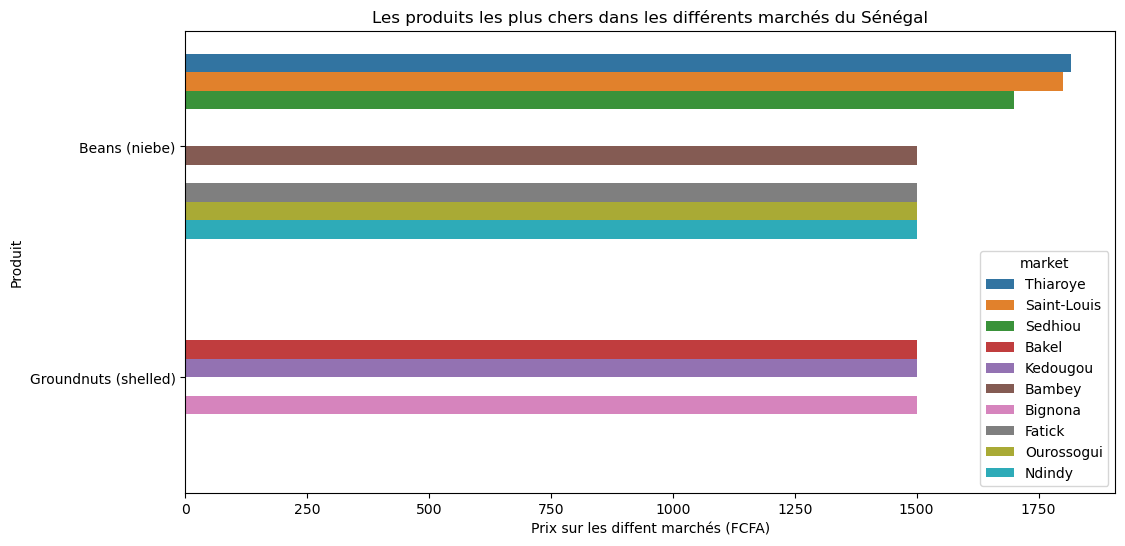

-------------------------------------------------------------------------------- 
Prix de vente des produit :                           commodity   price
0              Groundnuts (shelled)  880.87
1                     Beans (niebe)  832.12
2    Rice (ordinary, first quality)  507.86
3            Groundnuts (unshelled)  459.24
4                Sorghum (imported)  365.61
5                      Rice (local)  326.30
6                   Rice (imported)  310.51
7   Rice (ordinary, second quality)  282.31
8                           Sorghum  252.73
9                            Millet  243.25
10                 Maize (imported)  239.80
11                    Maize (local)  229.17


In [24]:
# Grouper les données par marché puis lister les produit les plus chers de chaque marché
prix_marche = df.loc[
    df.groupby('market')['price']
    .idxmax(),
    ['admin1', 'market', 'commodity', 'price']
].sort_values('price', ascending=False)

# Visualisation des données
print('\n Top 10 des marchés avec le prix ponctuel le plus élevé enregistré, et le produit concerné :\n')
print(prix_marche.sort_values('price', ascending=False).head(10))

# Visualisation du graphique
print('-'*80, '\nVisualisation du graphique :')
top10 = prix_marche.sort_values('price', ascending=False).head(10)

# Graphique
plt.figure(figsize=(12,6))
sns.barplot(data=top10,
            x='price',
            y='commodity',
            hue='market')

# Mise en forme du graphique
plt.title('Les produits les plus chers dans les différents marchés du Sénégal')
plt.xlabel('Prix sur les diffent marchés (FCFA)')
plt.ylabel('Produit')

# Affichage du graphique
plt.show()

# Prix de vente moyen des produits
prix_moyen = df.groupby('commodity')['price'].mean().round(2).sort_values(ascending=False).reset_index()


print('-'*80, '\nPrix de vente des produit :', prix_moyen)

**1. Produits les plus chers par marché**

**Interprétation :** Avec un prix de vente nationnal moyen de **8320** et de **880 XOF/KG**, les **haricots niébé (Beans niebe)** et les **arachides décortiquées (Groundnuts shelled)** sont les produit les plus chers* avec des pics à Thiaroye-Dakar (**jusqu'à 1816 XOF/kg**), Saint-Louis et Sédhiou. Ce sont des légumineuses à forte valeur protéique, sensibles aux aléas climatiques et à la demande.

**Recommandation :** surveiller en priorité ces deux filières (niébé, arachide) car elles tirent les indices de prix vers le haut. Il faut envisager egalement des stocks de sécurité ciblés sur ces produits.

#### **2. Evolution des prix des produits alimentaires au fil du temps**

On observe la trajectoire annuelle moyenne du prix (en XOF/kg) pour chaque produit, ainsi que l'évolution du prix moyen global.



Evolution des prix des produits alimentaires sur le marché Sénégalais :
            date                       commodity   price  usdprice
0    2000-01-15                Maize (imported)  149.00      0.35
1    2000-01-15                          Millet  124.75      0.30
2    2000-01-15                 Rice (imported)  227.50      0.54
3    2000-01-15                         Sorghum  125.00      0.30
4    2000-02-15                Maize (imported)  150.00      0.36
...         ...                             ...     ...       ...
1939 2026-03-15                 Rice (imported)  328.78      0.57
1940 2026-03-15                    Rice (local)  395.96      0.69
1941 2026-03-15  Rice (ordinary, first quality)  503.11      0.88
1942 2026-03-15                         Sorghum  318.52      0.56
1943 2026-03-15              Sorghum (imported)  303.75      0.53

[1944 rows x 4 columns]
-------------------------------------------------------------------------------- 
Visualisation du graphique 

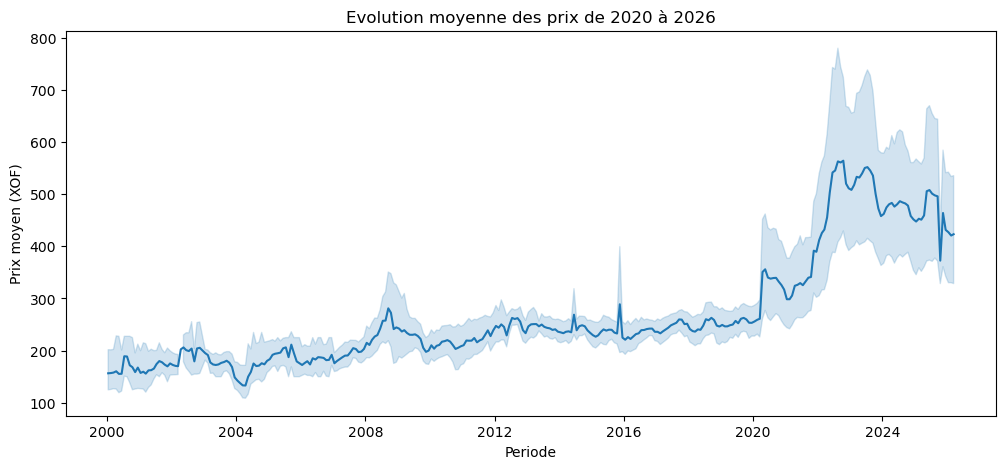

-------------------------------------------------------------------------------- 
Visualisation interactive :


In [ ]:
# Evolution globale des prix des produits alimentaires sur le marché Sénégalais
evolution_globale = df.groupby(['date', 'commodity'])[['price', 'usdprice']].mean().round(2).reset_index()

# Visualisation des données
print('\nEvolution des prix des produits alimentaires sur le marché Sénégalais :\n', evolution_globale)

# Visualisation des données
print('-'*80, '\nVisualisation du graphique :')

# Graphique Seaborn
plt.figure(figsize=(12,5))
sns.lineplot(data=evolution_globale,
             x='date',
             y='price'
)

# Mise en forme du graphique
plt.title('Evolution moyenne des prix de 2020 à 2026')
plt.xlabel("Periode")
plt.ylabel("Prix moyen (XOF)")

# Affichage du graphique
plt.show()

#------------------------------------------------------------------------------------------------------

# Graphique Plotly interactif
evolution_prix = df.groupby(['date', 'commodity'])[['price', 'usdprice']].mean().round(2).reset_index()

# Visualisation des données
print('-'*80, '\nVisualisation interactive :')

graph = px.line(evolution_prix.reset_index(),
                x='date',
                y='price',
                color='commodity',
                title='Évolution des prix des produits alimentaires sur le marché Sénégalais (en XOF)',)
graph.show()

**2. Évolution des prix dans le temps**

**Interprétation :** les prix des denrées de base (maïs, mil, sorgho, riz local) sont restés relativement stables autour de **150-300 XOF** jusqu'en 2020, mais on observe depuis une flambée spectaculaire du niébé et des arachides, qui atteignent des pics au-delà de **1000-1200 XOF** entre 2022 et 2025, avec une forte volatilité. *Cela coïncide avec les chocs post-Covid et la crise des prix alimentaires mondiaux.*

**Recommandation :** les autorités et acteurs de la sécurité alimentaire devraient prioriser un suivi renforcé et des mesures de stabilisation telque : *des stocks tampons, le soutien à la production locale, la subventions ciblées* des céréales de base afin de protéger le pouvoir d'achat des ménages les plus vulnérables.



#### **3. Les régions présentent les prix alimentaires moyens les plus élevés**

On calcul le prix moyen des produit par region, en suite on fait un classement des regions par ordre decroissant par rapport au prix moyen obtenu.


Les régions présentent les prix alimentaires moyens les plus élevés :
          admin1   price
0      Kedougou  406.93
1    Ziguinchor  397.10
2       Sedhiou  394.04
3         Matam  348.89
4         Thies  345.08
5         Kolda  341.20
6        Fatick  326.33
7   Saint Louis  325.75
8   Tambacounda  325.53
9      Diourbel  322.59
10        Dakar  308.56
11      Kaolack  306.43
12        Louga  304.16
13     Kaffrine  292.03
-------------------------------------------------------------------------------- 
Visualisation du graphique :


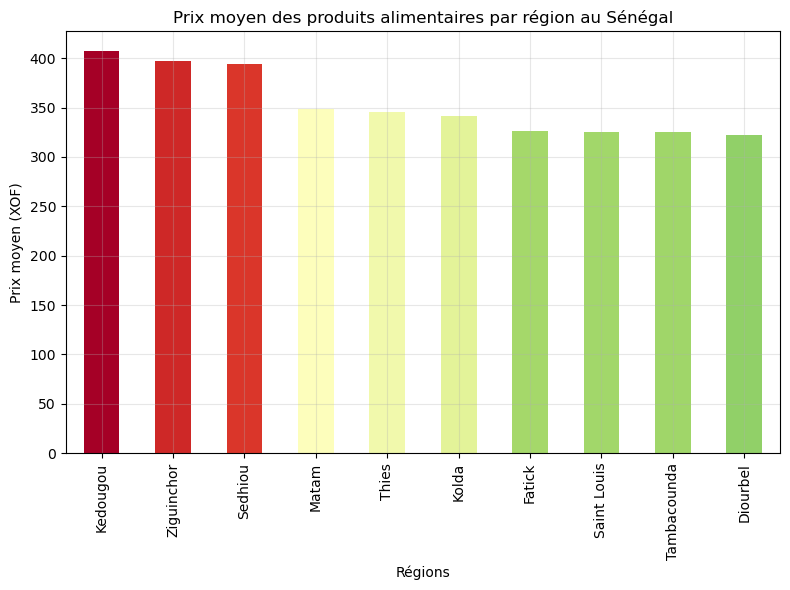

-------------------------------------------------------------------------------- 
Carte interactive du prix des produits par region :


In [ ]:
# Groupement des données par regions et par produit
prix_pregion = df.groupby('admin1')['price'].mean().round(2).sort_values(ascending=False)

# Visualisation des données
print('\nLes régions présentent les prix alimentaires moyens les plus élevés :\n', prix_pregion.reset_index().to_string(index=True))

# Visualisation du graphique
print('-'*80, '\nVisualisation du graphique :')
colors = plt.cm.RdYlGn_r((prix_pregion - prix_pregion.min()) / (prix_pregion.max() - prix_pregion.min()))
prix_pregion.head(10).plot(kind='bar',
                      figsize=(8, 6),
                      color=colors)
#plt.xticks(rotation=45)
plt.title('Prix moyen des produits alimentaires par région au Sénégal')
plt.xlabel('Régions')
plt.ylabel('Prix moyen (XOF)')
plt.tight_layout()
plt.grid(alpha=0.3)

plt.show()

#------------------------------------------------------------------------------------------------------

# Graphique Plotly interactif
print('-'*80, '\nCarte interactive du prix des produits par region :')

fig = px.scatter_map(
    df,
    lat="latitude",
    lon="longitude",
    color='commodity',
    hover_data=['date', 'market', 'price'],
    hover_name="commodity",
)

fig.show()

**3. Régions aux prix moyens les plus élevés**

**Interprétation :** Situées dans le sud/sud-est et plus enclavées,  **Kédougou, Ziguinchor et Sédhiou ont les prix les plus hauts**. Dakar, Kaolack et Kaffrine, situées dans les zones plus connectées aux grands axes ont les prix les plus bas. *Le constat est que l'éloignement logistique semble peser plus que le pouvoir d'achat local*.

**Recommandation :** Investir dans les infrastructures de transport et de stockage vers ces régions périphériques contribuerait a réduire les surcoûts logistiques que connait ces régions.

#### **4. Les départements enregistrent les plus fortes variations de prix**

On calcul le le coefficient de variation des prix par département apres avoir regrouper les prix moyen, l’écart-type par region.


 coefficient de variation par département :
                 mean     std  count    cv
admin2                                   
Sedhiou       394.04  253.60    894  0.64
Nioro Du Rip  300.99  189.60   1672  0.63
Saint Louis   343.31  217.59   2655  0.63
Mbour         340.88  212.08   1041  0.62
Ziguinchor    391.15  241.54   1393  0.62
Bambey        321.29  195.63   1154  0.61
Pikine        339.30  207.35   1110  0.61
Kolda         341.20  207.58   3042  0.61
Koumpentoum   298.52  178.77   2070  0.60
Bignona       414.86  248.94   1037  0.60
-------------------------------------------------------------------------------- 
Visualisation de la variation des prix par département :



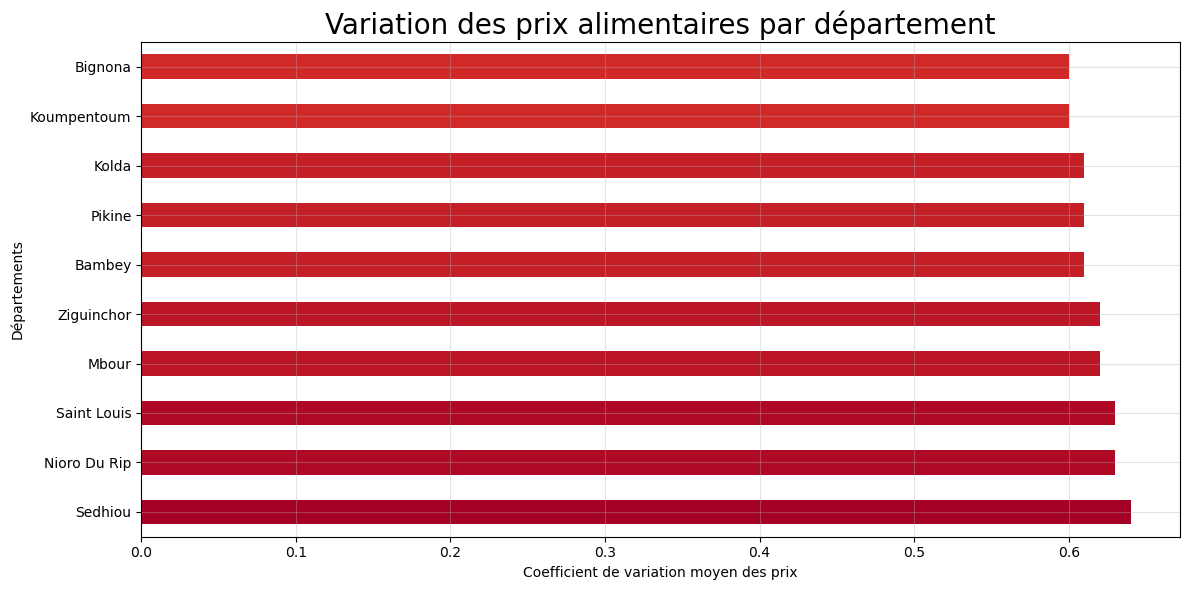

In [37]:
# Variation des prix alimentaires par departement
var_prix = df.groupby('admin2')['price'].agg(['mean', 'std', 'count']).round(2)
var_prix['cv'] = (var_prix['std'] / var_prix['mean']).round(2)

cv_var = var_prix.groupby('admin2')['cv'].mean().sort_values(ascending=False)

# Visiualisation des données
print('\n coefficient de variation par département :\n',
      var_prix
      .sort_values('cv', ascending=False)
      .head(10)
)

# Visualisation du graphique
print('-'*80, '\nVisualisation de la variation des prix par département :\n')
colors = plt.cm.RdYlGn_r((cv_var - cv_var.min()) / (cv_var.max() - cv_var.min()))
cv_var.head(10).plot(kind='barh', figsize=(12, 6), color=colors)

plt.title('Variation des prix alimentaires par département', fontsize=20)
plt.xlabel('Coefficient de variation moyen des prix')
plt.ylabel('Départements')
plt.grid(alpha=0.35)
plt.tight_layout()

plt.show()

**Interprétation :** **Sédhiou, Saint-Louis et Nioro du Rip** affichent les plus forts coefficients de variation d’environ **0.63** a **0.64**, suivis de près par Mbour et Ziguinchor, tandis que Bignona et Koumpentoum sont relativement plus stables d’environ **0.60**. *L'écart entre le département le plus et le moins volatil reste toutefois faible* (**0.04 point**), signe que l'instabilité des prix touche presque uniformément tout le pays plutôt qu'une poignée de zones isolées.

**Recommandation :** prioriser un dispositif de suivi renforcé et de stocks de sécurité dans les départements en tête (Sédhiou, Saint-Louis, Nioro du Rip), tout en gardant une veille nationale, puisque même les départements les *"moins volatils"* du classement restent très instables en valeur absolue.

#### **5. Les marchés présentent les prix les plus élevés et les plus faibles**

On calcul le prix moyen par marché et on ordonne par Croissant puis on affiche les head et les tail dans deux variables differente.


Marchés présentent les prix les plus élevés :
        market   price
0    Salémata  456.08
1        Mako  432.41
2  Saint-Maur  430.52
3     Bignona  414.86
4     Sedhiou  394.04
-------------------------------------------------------------------------------- 
Marchés présentent les prix les plus faibles :
           market   price
0           Mbar  220.88
1    Diama Gadio  219.95
2      Koungueul  209.75
3      Velingara  191.64
4  Dioli Mandakh  181.15
-------------------------------------------------------------------------------- 
Visualisation des top 5 des marchés présentent les prix les plus élevés et les plus faibles :



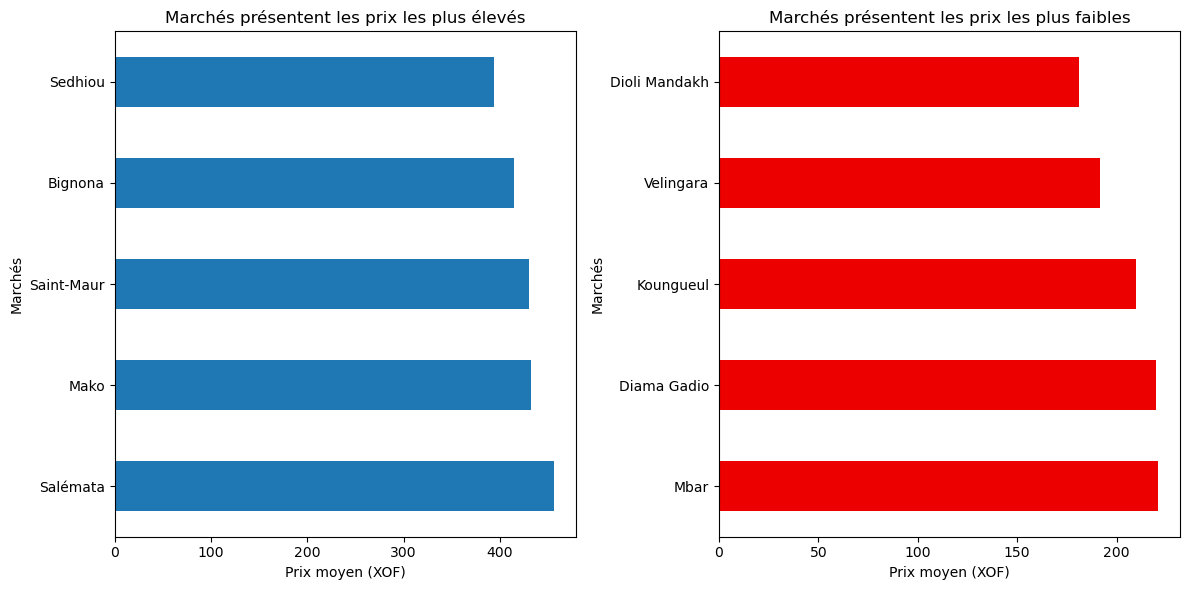

In [38]:
# Calcul de prix moyen par marché
marches = df.groupby('market')['price'].mean().round(2).sort_values(ascending=False)

# Visualisation des données des marchés présentent les prix les plus élevés
print('\nMarchés présentent les prix les plus élevés :\n',
      marches.head()
      .reset_index()
      .to_string(index=True))

# Visualisation des données des marchés présentent les prix les plus faibles
print('-'*80,'\nMarchés présentent les prix les plus faibles :\n',
      marches.tail()
      .reset_index()
      .to_string(index=True))

# Visualisation du graphique des top 5 des marchés présentent les prix les plus élevés et les plus faibles
print('-'*80, '\nVisualisation des top 5 des marchés présentent les prix les plus élevés et les plus faibles :\n')

# Graphique des marchés présentent les prix les plus élevés
plt.subplot(1, 2, 1)
marches.head(5).plot(kind='barh', figsize=(12,6))
plt.title('Marchés présentent les prix les plus élevés')
plt.xlabel('Prix moyen (XOF)')
plt.ylabel('Marchés')
plt.tight_layout()

# Graphique des marchés présentent les prix les plus faibles
plt.subplot(1, 2, 2)
marches.tail(5).plot(kind='barh', figsize=(12,6), color="#EC0000")
plt.title('Marchés présentent les prix les plus faibles')
plt.xlabel('Prix moyen (XOF)')
plt.ylabel('Marchés')
plt.tight_layout()

plt.show()

**5. Marchés extrêmes (les plus chers / moins chers)**
**Interprétation :** **Salémata et Mako** (*zones reculées de Kédougou*) sont les marchés les **plus chers** ; **Diola Mandakh et Vélingara** les **moins chers**. L'écart peut dépasser un facteur **2.5**.

**Recommandation :** Améliorer la desserte routière et l'information sur les prix sur les marchés isolés pour limiter les rentes de situation des intermédiaires.

#### **6. Les produits qui connaissent les plus fortes fluctuations de prix selon les périodes**

On regroupe les date par année 


Coefficient de variation par produit :
    index               commodity        mean         std        cv
0      0           Beans (niebe)  832.124053  271.547824  0.326331
1      1    Groundnuts (shelled)  880.870387  187.211142  0.212530
2      2  Groundnuts (unshelled)  459.243940  147.808336  0.321851
3      3        Maize (imported)  239.801875   61.829951  0.257838
4      4           Maize (local)  229.168780   64.629367  0.282016
-------------------------------------------------------------------------------- 
Visualisation du coefficient de variation par produit :



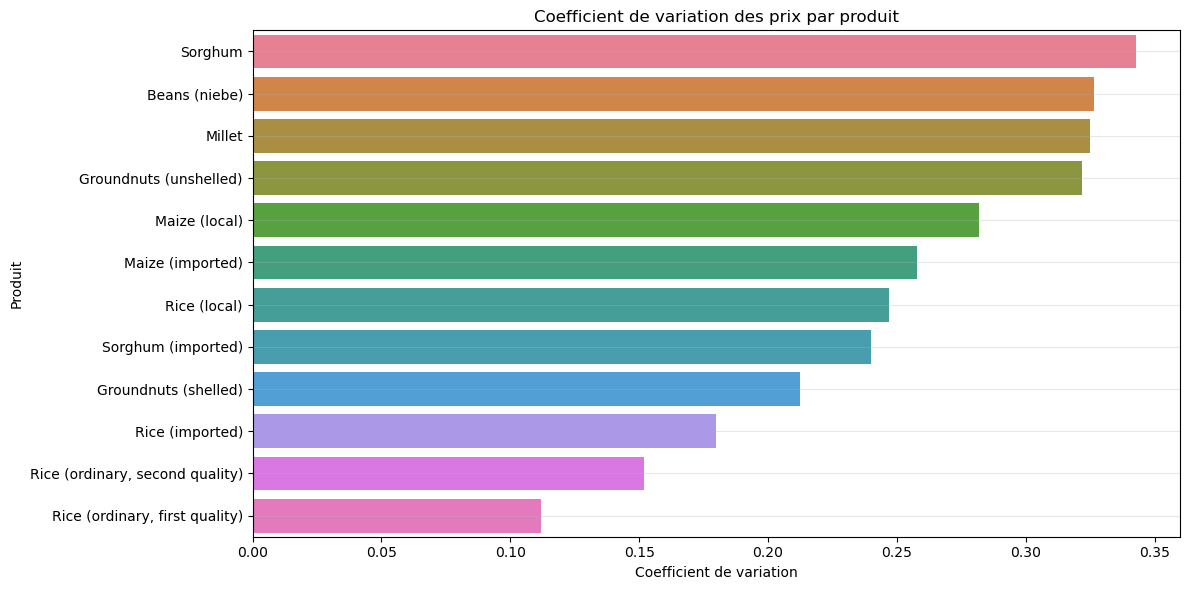

In [89]:
# Calcul du coefficient de variation par année et produit
grp_prod = (
    df.groupby('commodity')['price']
      .agg(mean='mean', std='std')
      .reset_index()
)

grp_prod['cv'] = grp_prod['std'] / grp_prod['mean']

# Visualisation des données des marchés présentent les prix les plus élevés
print('\nCoefficient de variation par produit :\n',
      grp_prod.head()
      .reset_index()
      .to_string(index=True))

# Visualisation du graphique 
print('-'*80, '\nVisualisation du coefficient de variation par produit :\n')

plt.figure(figsize=(12,6))

sns.barplot(
    data=grp_prod.sort_values('cv', ascending=False),
    x='cv',
    y='commodity',
    hue='commodity',
    legend=False
)

plt.xticks(rotation=0)
plt.title("Coefficient de variation des prix par produit")
plt.xlabel('Coefficient de variation')
plt.ylabel('Produit')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Coefficient de variation par année et produit :
         date         commodity        mean       std        cv
1 2000-12-31            Millet  126.191000  4.878232  0.038658
0 2000-12-31  Maize (imported)  153.138000  5.624567  0.036729
3 2000-12-31           Sorghum  124.785714  2.888921  0.023151
2 2000-12-31   Rice (imported)  225.309167  4.821602  0.021400
4 2001-12-31  Maize (imported)  164.705000  8.388519  0.050931
-------------------------------------------------------------------------------- 
Visualisation du coefficient de variation par année et produit :



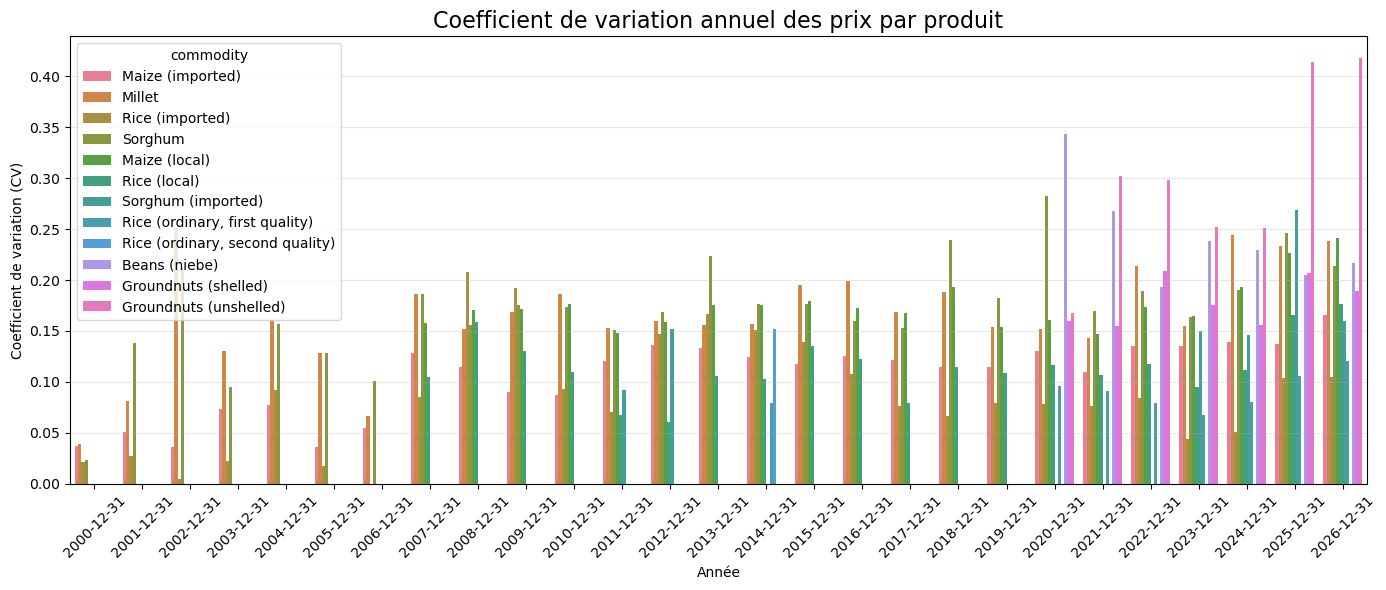

In [91]:
# Calcul du coefficient de variation par année et produit
grp_prod = (
    df.groupby([pd.Grouper(key='date', freq='YE'), 'commodity'])['price']
      .agg(mean='mean', std='std')
      .reset_index()
)

grp_prod['cv'] = grp_prod['std'] / grp_prod['mean']

# Affichage
print('\nCoefficient de variation par année et produit :\n',
      grp_prod.head()
      .sort_values(['date', 'cv'], ascending=[True, False])
      .to_string())

# Graphique
print('-'*80, '\nVisualisation du coefficient de variation par année et produit :\n')

plt.figure(figsize=(14,6))

sns.barplot(
    data=grp_prod,
    x='date',
    y='cv',
    hue='commodity'
)

plt.xticks(rotation=45)
plt.title("Coefficient de variation annuel des prix par produit", fontsize=16)
plt.xlabel("Année")
plt.ylabel("Coefficient de variation (CV)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**6. Fluctuations annuelles par produit**
**Interprétation** : le **riz importé** était le produit "pic" dominant jusqu'en **2019** ; depuis **2020**, ce sont les **niébés** et l'**arachide** qui enregistrent les pics annuels les plus marqués, signe d'un déplacement de la pression inflationniste des céréales importées vers les **produits locaux**.

**Recommandation** : diversifier les sources d'approvisionnement en produsent localement et en creant des réserves régionales plutôt que de se concentrer uniquement sur la sécurisation du riz importé.

#### **7. Observation sur les différences de prix entre les catégories de produits alimentaires**

On calcul les diffence entre les prix moyen, l’écat-type, le prix moyen et le prix minimum


Différences de prix entre les catégories de produits alimentaires :
                       mean     std     max    min
category                                         
cereals and tubers  278.61   95.74   840.0   90.0
pulses and nuts     747.54  280.53  1816.5  200.0
La differance est de :  468.93
-------------------------------------------------------------------------------- 
Evolution mensuelle des prix par produits selon les periodes :
            date                       commodity   price  usdprice
0    2000-01-15                Maize (imported)  149.00      0.35
1    2000-01-15                          Millet  124.75      0.30
2    2000-01-15                 Rice (imported)  227.50      0.54
3    2000-01-15                         Sorghum  125.00      0.30
4    2000-02-15                Maize (imported)  150.00      0.36
...         ...                             ...     ...       ...
1939 2026-03-15                 Rice (imported)  328.78      0.57
1940 2026-03-15          

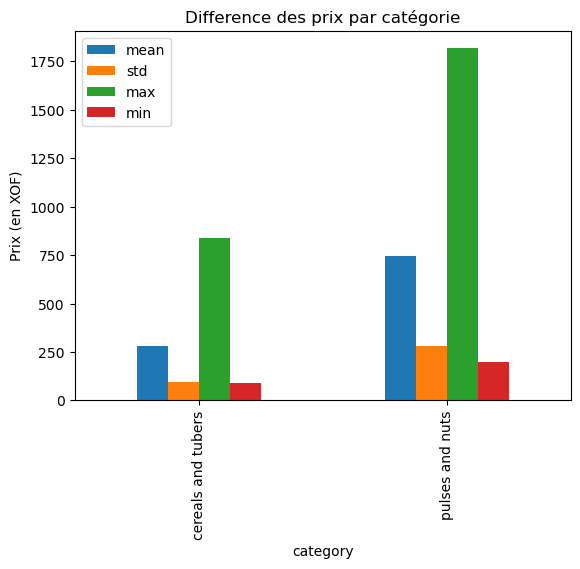

-------------------------------------------------------------------------------- 
Visualisation du difference des prix par catégorie boxplot :



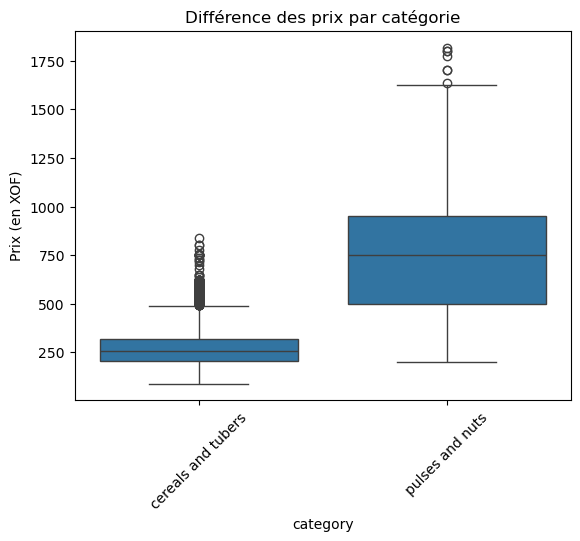

In [98]:
# Calculer le prix moyen par catecogorie
prix_categorie = (df.groupby('category')['price']
                  .agg(['mean', 'std', 'max','min'])
                  .round(2))

dif = (
    df.loc[df['category'] == 'pulses and nuts', 'price'].mean()
    - df.loc[df['category'] == 'cereals and tubers', 'price'].mean()
)
dif = round(dif, 2)

# Visualisation des données
print('\nDifférences de prix entre les catégories de produits alimentaires :\n',prix_categorie)
print('La differance est de : ', dif)

# Visualisation des données
print('-' * 80,'\nEvolution mensuelle des prix par produits selon les periodes :\n', evolution_globale)

# Visualisation du descriptif des prix par catégorie
print('-' * 80,'\nVisualisation du difference des prix par catégorie :\n')
prix_categorie.plot(kind='bar')

plt.title("Difference des prix par catégorie")
plt.ylabel("Prix (en XOF)")
plt.show()

# Visualisation du boxplot
prix_ctg = prix_categorie.reset_index()
print('-' * 80,'\nVisualisation du difference des prix par catégorie boxplot :\n')
sns.boxplot(
    data=df, 
    x='category',
    y='price'
)

plt.xticks(rotation=45)
plt.title("Différence des prix par catégorie")
plt.ylabel("Prix (en XOF)")
plt.show()

**7. Écart entre catégories (céréales/tubercules vs légumineuses)**

**Interprétation** : Les légumineuses coûtent en moyenne **469 XOF** de plus que les céréales/tubercules soit **748 vs 279 XOF**, avec une dispersion (std) presque 3 fois plus élevée — un produit plus cher est aussi plus instable.

**Recommandation** : Orienter les programmes de soutien alimentaire davantage vers les céréales car ils son moins chères et plus stables. Mais aussi subventionner les légumineuses en période de pic.

#### **8. variation des prix selon les types de prix et des unités de mesure**

On cherche les different unité d’homognéité on fait la comparaison

In [102]:
# Verification des differentes type de ventes, d’unités, et de periode de ventes
print('Type de prix (pricetype) présents: ', df['pricetype'].unique())
print('Unité de mesure (unit) présents: ', df['unit'].unique())
print('Indicateurs de qualité (priceflag) présents: ', df['priceflag'].unique())


Type de prix (pricetype) présents:  ['Retail']
Unité de mesure (unit) présents:  ['KG']
Indicateurs de qualité (priceflag) présents:  ['actual']


**8. Homogénéité type de prix / unité / qualité**

**Remarque** : Comme évoqué au debut de notre analyse, le jeu de données ne contient qu'un seul type de prix (**Retail**) et une seule unité (**KG**) il n’y a donc pas de comparaison possible.

#### **9. Les produits présentent les prix en USD les plus élevés sur les différents marchés**

On fait comme dans 1. avec la colonne usdprice


 Top 10 des produits présentent les prix en USD les plus élevés sur les différents marchés :

            market             commodity  usdprice
39079  Saint-Louis         Beans (niebe)      2.95
34656     Thiaroye         Beans (niebe)      2.87
34870      Sedhiou         Beans (niebe)      2.69
48282   Saint-Maur  Groundnuts (shelled)      2.68
48229  Tambacounda  Groundnuts (shelled)      2.68
47274       Bambey  Groundnuts (shelled)      2.67
48726        Bakel  Groundnuts (shelled)      2.65
38436       Tilene         Beans (niebe)      2.58
37409       Fatick         Beans (niebe)      2.54
38052      Bignona  Groundnuts (shelled)      2.50
-------------------------------------------------------------------------------- 
Visualisation du graphique :


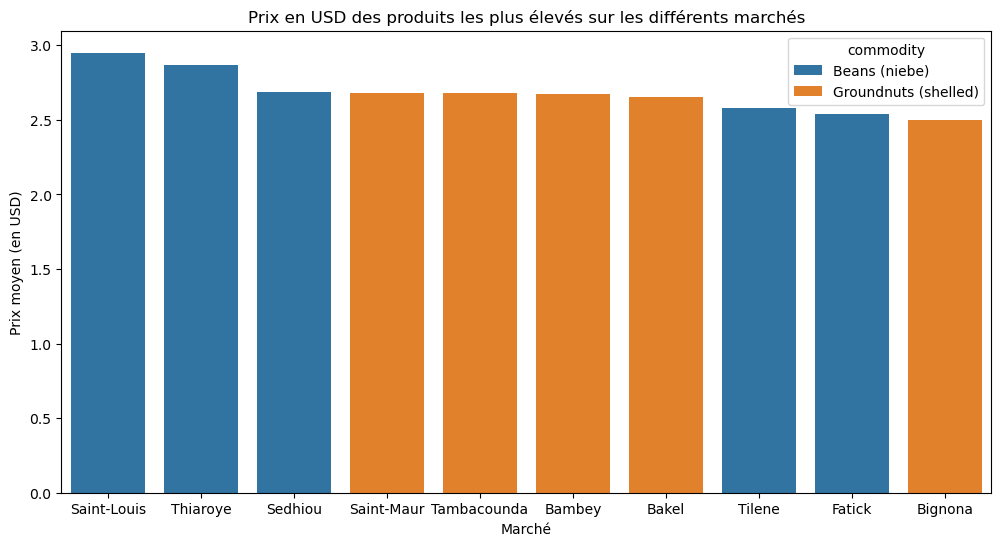

In [106]:
# Identifier le produits qui a le prix le plus élevé en USD de chaque marché et les listé
usdprice_marche = df.loc[
    df.groupby('market')['usdprice']
    .idxmax(),
    ['market', 'commodity', 'usdprice']
].sort_values('usdprice', ascending=False)

# Visualisation des données
print('\n Top 10 des produits présentent les prix en USD les plus élevés sur les différents marchés :\n')
print(usdprice_marche.head(10))

# Visualisation du graphique
print('-'*80, '\nVisualisation du graphique :')
top10 = usdprice_marche.head(10)

# Graphique
plt.figure(figsize=(12,6))
sns.barplot(data=top10,
            x='market',
            y='usdprice',
            hue='commodity')

# Mise en forme du graphique
plt.title('Prix en USD des produits les plus élevés sur les différents marchés')
plt.xlabel('Marché')
plt.ylabel('Prix moyen (en USD)')

# Affichage du graphique
plt.show()

**9. Produits les plus chers en USD par marché**
**Interprétation** : Cohérent avec le point 1, le niébé et l’arachide décortiquée dominent aussi en **USD**.

**Recommandation** : ces produits étant chers autant en monnaie locale qu'en devise forte, une intervention sur l'offre locale sera plus efficace qu'une politique de change.

#### 10. recommandations proposées pour améliorer le suivi et la compréhension des prix alimentaires au Sénégal 

**Insight et recommandation**

1. Mettre en place un tableau de bord actualisé mensuellement pour anticiper les chocs de prix.

2. Prioriser la surveillance des légumineuses (niébé, arachide) qui sont les moteurs actuels de l'inflation alimentaire.

3. Renforcer les infrastructures et la logistique vers Kédougou, Sédhiou et Ziguinchor, régions structurellement chères et volatiles.

4. Encourager la production et la transformation locales pour réduire la dépendance aux importations.

5. Étendre la collecte de données aux prix de gros pour des analyses plus fines de la chaîne de valeur.

6. Publier les prix moyens par marché pour renforcer la transparence et controler reculierement sur le terrain pour limiter les abus entre producteurs, commerçants et consommateurs.